# Additional Analysis: IoT Predictive Maintenance Project

Companion to the main notebook. These analyses use only what we have: the **numbers in the report (Table V)** and the **deployed model files** (`model.h`, `scaler_params.h`). We do not have the raw sensor CSVs here, so nothing below re-trains a model or measures accuracy on real data.

| # | Analysis | Data used |
|---|---|---|
| A | Are the six classifiers statistically distinguishable? | Report Table V (mean, std, 5 folds) |
| B | What do the forest's decision thresholds mean in physical units? | `model.h` + `scaler_params.h` |
| C | Structure and compute cost of the on-device model | `model.h` |
| D | Experiments we still need real data for | (planning only) |

## 0. Setup: load the deployed model

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

In [2]:
import re, os

MODEL_PATH  = "motor_classifier_2class/model.h"
SCALER_PATH = "motor_classifier_2class/scaler_params.h"
assert os.path.exists(MODEL_PATH), "Put the motor_classifier_2class folder next to this notebook."

src = open(MODEL_PATH).read()
parts = re.split(r"//\s*tree\s*#\d+", src)[1:]

TOK = re.compile(r"if \(x\[(\d+)\] <= ([-+0-9.eE]+)\) \{|else \{|\}|votes\[(\d+)\] \+= 1;")

def parse_tree(text):
    toks = [m for m in TOK.finditer(text)]
    pos = 0
    def node():
        nonlocal pos
        m = toks[pos]; pos += 1
        s = m.group(0)
        if s.startswith("votes"):
            return ("leaf", int(m.group(3)))
        assert s.startswith("if"), s
        feat, thr = int(m.group(1)), float(m.group(2))
        left = body()
        assert toks[pos].group(0).startswith("else"); pos += 1
        right = body()
        return ("split", feat, thr, left, right)
    def body():
        nonlocal pos
        n = node()
        assert toks[pos].group(0) == "}"; pos += 1
        return n
    return node()

trees = [parse_tree(p) for p in parts]

def depth(n):  return 0 if n[0] == "leaf" else 1 + max(depth(n[3]), depth(n[4]))
def leaves(n): return 1 if n[0] == "leaf" else leaves(n[3]) + leaves(n[4])
def splits(n, acc):
    if n[0] == "split":
        acc.append(n[1]); splits(n[3], acc); splits(n[4], acc)
    return acc

scaler_src = open(SCALER_PATH).read()
mean  = np.array(eval(re.search(r"feature_mean\[\]\s*=\s*\{(.*?)\}", scaler_src).group(1).replace("f", "")))
scale = np.array(eval(re.search(r"feature_scale\[\]\s*=\s*\{(.*?)\}", scaler_src).group(1).replace("f", "")))
features = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z", "period_us"]
classes = {0: "normal", 1: "abnormal"}

print(f"Trees parsed        : {len(trees)}")
print(f"Max depth per tree  : {[depth(t) for t in trees]}")
print(f"Leaves per tree     : {[leaves(t) for t in trees]}")
print(f"Total decision nodes: {sum(len(splits(t, [])) for t in trees)}")
print(f"model.h size        : {os.path.getsize(MODEL_PATH)/1024:.1f} KB of source")

Trees parsed        : 12
Max depth per tree  : [6, 6, 6, 5, 5, 5, 4, 4, 4, 6, 4, 6]
Leaves per tree     : [13, 10, 29, 11, 9, 8, 10, 6, 6, 14, 7, 10]
Total decision nodes: 121
model.h size        : 30.0 KB of source


In [3]:
def collect(n, acc):
    if n[0] == "split":
        acc.append((n[1], n[2])); collect(n[3], acc); collect(n[4], acc)
    return acc
thr = [(f, t) for tr in trees for (f, t) in collect(tr, [])]
print(f"{len(trees)} trees, {len(thr)} split thresholds loaded")

12 trees, 121 split thresholds loaded


## A. Are the six classifiers statistically distinguishable?

The report gives mean grouped-CV accuracy and standard deviation over **5 folds**. From those summaries we can compute a 95% confidence interval for each model's mean (Student t, 4 degrees of freedom) and run a Welch t-test of the deployed model against each other model.

**Caveats (important):** with only 5 folds the intervals are wide; folds share data and are not independent, and we do not have per-fold scores for a paired test. So the p-values are *indicative*, not rigorous. We also assume the reported "±" is the sample standard deviation.

,mean,std,CI low,CI high
RF 12 trees d=6 (deployed),0.84,0.09,0.728,0.952
RF 300 trees,0.79,0.05,0.728,0.852
SVM (RBF),0.77,0.06,0.696,0.844
Gradient Boosting,0.78,0.04,0.730,0.830
KNN,0.75,0.07,0.663,0.837
Logistic Regression,0.76,0.05,0.698,0.822
MLP,0.79,0.06,0.716,0.864


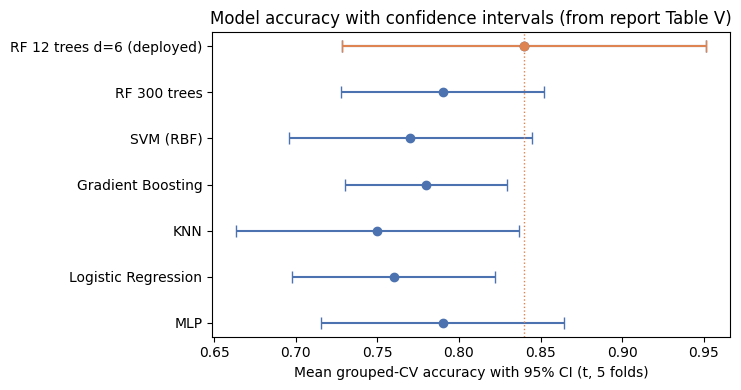

In [4]:
models = ["RF 12 trees d=6 (deployed)", "RF 300 trees", "SVM (RBF)", "Gradient Boosting",
          "KNN", "Logistic Regression", "MLP"]
mean_ = np.array([0.84, 0.79, 0.77, 0.78, 0.75, 0.76, 0.79])
std_  = np.array([0.09, 0.05, 0.06, 0.04, 0.07, 0.05, 0.06])
n_folds = 5

tcrit = stats.t.ppf(0.975, df=n_folds - 1)
half = tcrit * std_ / np.sqrt(n_folds)
ci = pd.DataFrame({"mean": mean_, "std": std_, "CI low": mean_ - half, "CI high": mean_ + half}, index=models).round(3)
display(ci)

fig, ax = plt.subplots(figsize=(7.5, 4))
y = np.arange(len(models))[::-1]
ax.errorbar(mean_, y, xerr=half, fmt="o", capsize=4, color="#4c72b0")
ax.errorbar(mean_[0], y[0], xerr=half[0], fmt="o", capsize=4, color="#dd8452")
ax.set_yticks(y); ax.set_yticklabels(models)
ax.set_xlabel("Mean grouped-CV accuracy with 95% CI (t, 5 folds)")
ax.set_title("Model accuracy with confidence intervals (from report Table V)")
ax.axvline(mean_[0], ls=":", c="#dd8452", lw=1)
plt.tight_layout(); plt.show()

In [5]:
rows = []
for i in range(1, len(models)):
    t, p = stats.ttest_ind_from_stats(mean_[0], std_[0], n_folds, mean_[i], std_[i], n_folds, equal_var=False)
    d = (mean_[0] - mean_[i]) / np.sqrt((std_[0]**2 + std_[i]**2) / 2)      # Cohen's d
    rows.append([models[i], round(mean_[0] - mean_[i], 3), round(t, 2), round(p, 3),
                 round(min(1, p * (len(models) - 1)), 3), round(d, 2)])
tests = pd.DataFrame(rows, columns=["vs deployed RF", "acc difference", "Welch t", "p (raw)",
                                    "p (Bonferroni x6)", "Cohen's d"])
display(tests)
print("Any raw p < 0.05:", bool((tests['p (raw)'] < 0.05).any()),
      "| any Bonferroni-adjusted p < 0.05:", bool((tests['p (Bonferroni x6)'] < 0.05).any()))

,vs deployed RF,acc difference,Welch t,p (raw),p (Bonferroni x6),Cohen's d
0,RF 300 trees,0.05,1.09,0.318,1.000,0.69
1,SVM (RBF),0.07,1.45,0.191,1.000,0.92
2,Gradient Boosting,0.06,1.36,0.226,1.000,0.86
3,KNN,0.09,1.77,0.118,0.707,1.12
4,Logistic Regression,0.08,1.74,0.131,0.786,1.10
5,MLP,0.05,1.03,0.336,1.000,0.65


Any raw p < 0.05: False | any Bonferroni-adjusted p < 0.05: False


**Reading the result.** The deployed forest has the highest mean, and the effect sizes against the weakest models (KNN, Logistic Regression) are moderate to large, but the intervals overlap heavily and no comparison is significant even before correcting for testing six models (smallest raw p is about 0.12, against KNN). In plain terms: **the data supports "the small forest is at least as good as the others", not "it is better."** The stable claim for the paper is the deployability result. A stronger claim would need per-fold scores, more recording segments, and a paired test.

## B. What do the forest's decision thresholds mean in physical units?

Trees split on *standardised* inputs. Converting each threshold back with `threshold x scale + mean` shows where in real units the model draws its lines. For `period_us` we also convert to RPM (assuming one Hall pulse per revolution, as in the firmware).

,feature,n splits,min,median,max,unit
0,accel_x,25,-0.239,2.237,2.417,m/s^2
1,accel_y,21,-7.845,-0.972,-0.400,m/s^2
2,accel_z,11,6.973,8.069,8.284,m/s^2
3,gyro_x,18,-0.810,-0.210,0.158,rad/s
4,gyro_y,13,0.031,0.070,1.703,rad/s
5,gyro_z,14,-0.065,0.009,0.055,rad/s
6,period_us,19,1242.605,8244.710,20027.335,us


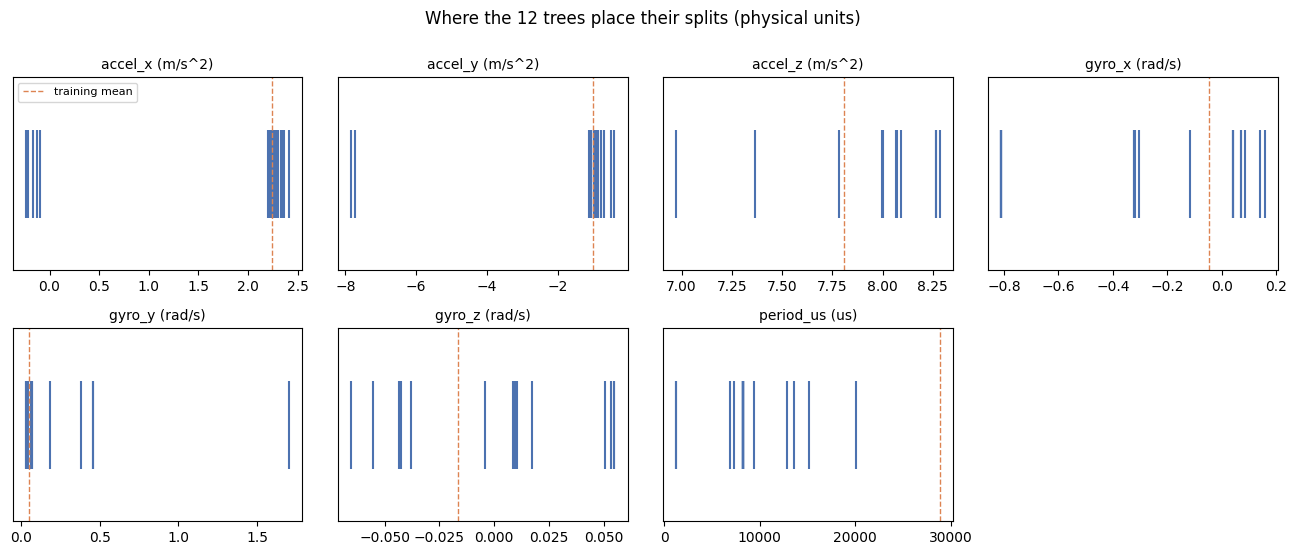

In [6]:
rows = []
phys = {}
for i, name in enumerate(features):
    ts = np.array([t for f, t in thr if f == i]) * scale[i] + mean[i]
    phys[name] = ts
    rows.append([name, len(ts), ts.min(), np.median(ts), ts.max()])
unit = {"accel_x": "m/s^2", "accel_y": "m/s^2", "accel_z": "m/s^2",
        "gyro_x": "rad/s", "gyro_y": "rad/s", "gyro_z": "rad/s", "period_us": "us"}
tab = pd.DataFrame(rows, columns=["feature", "n splits", "min", "median", "max"])
tab["unit"] = tab["feature"].map(unit)
display(tab.round(3))

fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, name in zip(axes.ravel(), features):
    ts = np.sort(phys[name])
    ax.eventplot(ts, orientation="horizontal", colors="#4c72b0", lineoffsets=0.5, linelengths=0.8)
    ax.axvline(mean[features.index(name)], color="#dd8452", ls="--", lw=1, label="training mean")
    ax.set_yticks([]); ax.set_title(f"{name} ({unit[name]})", fontsize=10)
axes.ravel()[-1].axis("off")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Where the 12 trees place their splits (physical units)", y=1.0)
plt.tight_layout(); plt.show()

In [7]:
p = phys["period_us"]
p_pos = np.sort(p[p > 0])
rpm_thr = 60e6 / p_pos
print(f"period_us thresholds > 0: {len(p_pos)} of {len(p)}")
print("Equivalent RPM boundaries (1 pulse/rev), sorted:")
print(np.round(np.sort(rpm_thr)).astype(int))
print("\nTraining-mean period = %.0f us -> about %.0f RPM" % (mean[6], 60e6 / mean[6]))

period_us thresholds > 0: 19 of 19
Equivalent RPM boundaries (1 pulse/rev), sorted:
[ 2996  3946  4428  4673  6418  7277  7277  7277  7277  7277  7277  7277
  7277  7277  7277  8221  8777 48286 48286]

Training-mean period = 28832 us -> about 2081 RPM


**What this tells us.** The `period_us` splits correspond to specific speed bands, so part of the model's decision depends on motor speed. Two details stand out in the output above:

- **One boundary is reused.** 10 of the 19 speed splits sit at the same value (about 7,277 RPM, period roughly 8,245 us). Many trees agree on one speed boundary, which usually means the training data has a clear gap or step in speed there.
- **Two splits sit near 48,000 RPM** (period about 1,243 us). That is far above what this motor and fan would plausibly reach, so those pulses are more likely electrical noise or double-triggering from the Hall sensor than real revolutions. The firmware only rejects periods under 100 us, so such glitches pass through. Worth checking in the raw data. That is reasonable (vibration scales with speed), but if the normal and abnormal recordings covered different speeds, speed alone could separate them. The check to run once we have the CSVs is to compare the RPM distributions of the two classes and evaluate accuracy within matched speed bands.

Note also that the mean of `accel_z` (about 7.8 m/s^2) and `accel_x` (about 2.2 m/s^2) reflect how the MPU6050 was mounted, since gravity is included in the readings. The model relies most on `accel_x` and `accel_y`, so **re-mounting the sensor at a different tilt would change the inputs and could change predictions.** This is why the firmware warns to keep the same orientation.

## C. Structure and compute cost of the on-device model

In [8]:
def leaf_classes(n, acc):
    if n[0] == "leaf": acc.append(n[1])
    else: leaf_classes(n[3], acc); leaf_classes(n[4], acc)
    return acc

rows = []
for k, tr in enumerate(trees, 1):
    lc = leaf_classes(tr, [])
    rows.append([k, depth(tr), len(lc), lc.count(0), lc.count(1)])
struct = pd.DataFrame(rows, columns=["tree", "depth", "leaves", "normal leaves", "abnormal leaves"]).set_index("tree")
display(struct)
print("Totals: leaves =", struct["leaves"].sum(),
      "| normal leaves =", struct["normal leaves"].sum(),
      "| abnormal leaves =", struct["abnormal leaves"].sum())

worst = int(struct["depth"].sum())
WIN = 200
print(f"\nWorst case per sample : {worst} comparisons (sum of tree depths)")
print(f"Worst case per 2 s window ({WIN} samples): {worst*WIN:,} comparisons")
print("Sample interval on the ESP32: 10 ms (100 Hz)")

,depth,leaves,normal leaves,abnormal leaves
tree,,,,
1,6,13,6,7
2,6,10,4,6
3,6,29,14,15
4,5,11,5,6
5,5,9,5,4
6,5,8,4,4
7,4,10,5,5
8,4,6,3,3
9,4,6,2,4


Totals: leaves = 133 | normal leaves = 63 | abnormal leaves = 70

Worst case per sample : 61 comparisons (sum of tree depths)
Worst case per 2 s window (200 samples): 12,200 comparisons
Sample interval on the ESP32: 10 ms (100 Hz)


**Compute and memory.** The forest is tiny: at most 61 threshold comparisons per sample and about 12,200 per 2-second window. An ESP32 (which typically runs at up to 240 MHz) can do that in a small fraction of the 10 ms sample interval, so inference is not the bottleneck; the 100 Hz sensor reads are. The model has 121 decision nodes, so as a rough estimate its data footprint is in the low kilobytes; check the exact figure in the Arduino IDE's compile output rather than trusting this estimate.

The leaf counts show how much of the tree structure is devoted to each class, which is a structural fact about the trained model, not a performance measure.

## D. Experiments that need the raw CSVs

These are the analyses that would actually strengthen the project, and what each would tell us:

1. **Per-fold scores for all six models** (same folds, same groups) - enables a paired test and settles whether the deployed forest is really better.
2. **Confusion matrix and per-class recall under grouped CV** - the report lists this as future work; important for Imbalance vs Misalignment confusability.
3. **Speed-matched evaluation** - compare classes within the same RPM band to rule out "the model is just detecting speed".
4. **Leave-one-recording-out CV** - the strictest test of generalisation to a new recording session.
5. **Feature-importance via permutation on held-out folds** - a proper importance measure, unlike the split-count used earlier.
6. **Orientation sensitivity** - rotate the accelerometer vector by small tilt angles in held-out data and measure how often predictions flip.
7. **Learning curve** - accuracy vs number of recording segments, to show whether more data would reduce the +/-0.09 spread.

If you share the CSVs (`normal_named.csv`, `abnormal_named.csv`, and the 900-window feature set), items 1-5 can be added to this notebook.